# 01 -- Units, dimensions, and dimensional analysis

| question | answer |
|---|---|
| What physics problem? | Is a candidate formula physically possible? |
| What mathematics? | Vector space of exponents over the seven SI base quantities. |
| What algorithm? | Add exponents on multiply; require equality on add (dimensional checking). |
| What software? | physkit.units.Dimension and Quantity; SymPy for symbolic checks. |
| What experiment? | Every measured quantity carries a unit set by its instrument. |
| What engineering application? | An ADC least-significant bit is a voltage; scaling must preserve units. |

This notebook follows the repository template: English explanation, mathematical derivation,
dimensions and SI units, SymPy derivation, NumPy implementation, Pandas tables, Matplotlib plots,
optional PyTorch, exercises, and engineering applications. It reuses the `physkit` package and the
results of earlier chapters.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## English explanation

Every physical quantity is a number times a unit. The unit encodes a **dimension** -- a product
of powers of the seven SI base quantities (length, mass, time, current, temperature, amount, luminous
intensity). A valid equation is dimensionally homogeneous: both sides carry the same dimension, and
only same-dimension quantities may be added. Dimensional analysis rejects impossible formulas before
any number is computed and often reveals the form of a law up to a constant.

Subject-verb-object: the instrument sets the unit; the dimension constrains the formula; the check
rejects the impossible.

## Mathematical derivation

Write a quantity's dimension as the exponent vector
$\mathbf{d}=(a_L,a_M,a_T,a_I,a_K,a_N,a_J)$. Multiplication of quantities adds these vectors; raising
to a power scales the vector; addition is defined only when the vectors are equal. This is exactly a
vector space over the rationals, and `physkit.units.Dimension` implements it. Energy, for example,
is force times length, i.e. $\mathbf{d}_E=(2,1,-2,0,0,0,0)$: $\mathrm{J}=\mathrm{kg\,m^2\,s^{-2}}$.

## Dimensions and SI units

In [2]:
print("ENERGY   =", U.ENERGY)
print("FORCE    =", U.FORCE)
print("VOLTAGE  =", U.VOLTAGE)
assert U.ENERGY == U.MASS * U.LENGTH**2 / U.TIME**2
assert U.VOLTAGE == U.ENERGY / U.CHARGE
# Planck * frequency is an energy; h/p is a length (de Broglie)
h = U.Quantity(C.H, U.ACTION)
print("h f  dimension:", (h * U.Quantity(1.0, U.FREQUENCY)).dim, "(expected ENERGY)")
print("h/p  dimension:", (h / U.Quantity(1.0, U.MASS * U.VELOCITY)).dim, "(expected LENGTH)")

ENERGY   = L^2 M^1 T^-2
FORCE    = L^1 M^1 T^-2
VOLTAGE  = L^2 M^1 T^-3 I^-1
h f  dimension: L^2 M^1 T^-2 (expected ENERGY)
h/p  dimension: L^1 (expected LENGTH)


## SymPy derivation

SymPy can carry symbolic base-dimension factors and confirm homogeneity. We verify the photon
relation $E=hc/\lambda$ is an energy and the diffraction-limit angle $\theta\sim\lambda/D$ is
dimensionless, symbolically.

In [3]:
L, M, T = sp.symbols('L M T', positive=True)
dim = {"h": M*L**2/T, "c": L/T, "lam": L, "E": M*L**2/T**2}
lhs = dim["E"]
rhs = dim["h"] * dim["c"] / dim["lam"]
assert sp.simplify(lhs - rhs) == 0
print("E = h c / lambda is dimensionally an energy:", sp.simplify(lhs/rhs), "(ratio = 1)")
assert sp.simplify(dim["lam"] / dim["lam"]) == 1     # theta ~ lambda/D dimensionless
print("theta ~ lambda / D is dimensionless")

E = h c / lambda is dimensionally an energy: 1 (ratio = 1)
theta ~ lambda / D is dimensionless


## NumPy implementation

With the dimensions confirmed, compute the numbers. The photon energy of light across the
visible band, in joules and electron-volts, via $E=hc/\lambda$.

In [4]:
lam_nm = np.array([400, 450, 500, 550, 600, 650, 700.0])
lam = lam_nm * C.NM
E_J = C.H * C.C / lam
E_eV = E_J / C.E
print("400 nm ->", round(float(E_eV[0]), 3), "eV ;  700 nm ->", round(float(E_eV[-1]), 3), "eV")

400 nm -> 3.1 eV ;  700 nm -> 1.771 eV


## Pandas tables

The SI constant set and the visible-band photon energies as tables (the constants come straight
from `physkit.constants`).

In [5]:
print(C.table().to_string(index=False))
print()
df = pd.DataFrame({"wavelength_nm": lam_nm, "energy_eV": np.round(E_eV, 3),
                   "frequency_THz": np.round(C.C / lam / 1e12, 1)})
print(df.to_string(index=False))

symbol     value_SI  unit
     c 2.997925e+08   m/s
     h 6.626070e-34   J s
  hbar 1.054572e-34   J s
     e 1.602177e-19     C
   k_B 1.380649e-23   J/K
   N_A 6.022141e+23 1/mol
  eps0 8.854188e-12   F/m
   m_e 9.109384e-31    kg
   m_p 1.672622e-27    kg
    a0 5.291772e-11     m
    Ry 1.360569e+01    eV
  mu_B 9.274010e-24   J/T
 alpha 7.297353e-03     1

 wavelength_nm  energy_eV  frequency_THz
         400.0      3.100          749.5
         450.0      2.755          666.2
         500.0      2.480          599.6
         550.0      2.254          545.1
         600.0      2.066          499.7
         650.0      1.907          461.2
         700.0      1.771          428.3


## Matplotlib plots

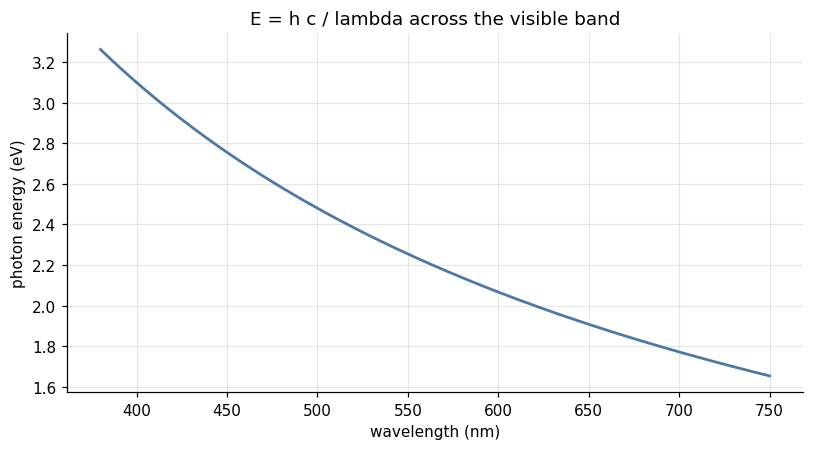

In [6]:
lam_c = np.linspace(380, 750, 400)
plt.figure()
plt.plot(lam_c, C.H * C.C / (lam_c * C.NM) / C.E)
plt.xlabel("wavelength (nm)"); plt.ylabel("photon energy (eV)")
plt.title("E = h c / lambda across the visible band")
plt.tight_layout(); plt.show()

## PyTorch (optional)

In [7]:
if torch is not None:
    lam_t = torch.tensor(lam, dtype=torch.float64)
    E_t = C.H * C.C / lam_t / C.E
    print("torch photon energies (eV):", [round(v, 3) for v in E_t.tolist()])
else:
    print("PyTorch absent -- the NumPy energies above are authoritative.")

PyTorch absent -- the NumPy energies above are authoritative.


## Exercises

1. Use dimensional analysis to recover the form of the gravitational period of a pendulum,
   $T\sim\sqrt{L/g}$, from the variables $L$ (length) and $g$ (acceleration).
2. Show with `physkit.units` that the fine-structure constant $\alpha=e^2/(4\pi\epsilon_0\hbar c)$ is
   dimensionless.
3. An ADC has full-scale $2.0\,\mathrm{V}$ and 12 bits. Compute the least-significant-bit voltage and
   confirm it has the dimension of voltage; express it in microvolts.

## Engineering applications

A **detector** outputs a voltage; an **ADC** maps that voltage to an integer code; the
least-significant bit $V_\text{LSB}=V_\text{FS}/2^{N}$ is itself a voltage, so any fixed-point scaling
in **firmware** must track the unit or the reconstructed physical value will be wrong by a power of
ten. Dimensional checking is the cheapest possible test of a signal-chain formula, and it runs before
any hardware exists.

Summary (subject-verb-object): the instrument sets units; the dimension vector constrains the law;
`physkit.units` rejects the inconsistent; the engineer scales without losing meaning.